In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv("insurance.csv")

print("Dataset loaded successfully!")
print(df.head())

Dataset loaded successfully!
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [4]:
print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(1338, 7)

Columns:
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB

Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [5]:
X = df.drop("charges", axis=1)
y = df["charges"]

print("Input Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Input Features:
   age     sex     bmi  children smoker     region
0   19  female  27.900         0    yes  southwest
1   18    male  33.770         1     no  southeast
2   28    male  33.000         3     no  southeast
3   33    male  22.705         0     no  northwest
4   32    male  28.880         0     no  northwest

Target:
0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64


In [6]:
numerical_features = ["age", "bmi", "children"]
categorical_features = ["sex", "smoker", "region"]

print("Numerical Features:", numerical_features)
print("Categorical Features:", categorical_features)

Numerical Features: ['age', 'bmi', 'children']
Categorical Features: ['sex', 'smoker', 'region']


In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessor created successfully!")

Preprocessor created successfully!


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

Training data size: (1070, 6)
Testing data size: (268, 6)


In [9]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree Regression": DecisionTreeRegressor(random_state=42),
    "Random Forest Regression": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )
}

print("Regression models created successfully!")

Regression models created successfully!


In [10]:
results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    })

results_df = pd.DataFrame(results)

print("Regression Model Performance:")
print(results_df)

Regression Model Performance:
                      Model          MAE           MSE         RMSE  R2 Score
0         Linear Regression  4181.194474  3.359692e+07  5796.284659  0.783593
1          Ridge Regression  4186.913072  3.362027e+07  5798.298795  0.783443
2  Decision Tree Regression  3227.664954  4.446327e+07  6668.078316  0.713600
3  Random Forest Regression  2549.151667  2.102544e+07  4585.350888  0.864569


In [11]:
results_display = results_df.copy()

results_display["MAE"] = results_display["MAE"].round(2)
results_display["MSE"] = results_display["MSE"].round(2)
results_display["RMSE"] = results_display["RMSE"].round(2)
results_display["R2 Score"] = results_display["R2 Score"].round(4)

results_display

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,4181.19,33596915.85,5796.28,0.7836
1,Ridge Regression,4186.91,33620268.92,5798.30,0.7834
2,Decision Tree Regression,3227.66,44463268.43,6668.08,0.7136
3,Random Forest Regression,2549.15,21025442.76,4585.35,0.8646


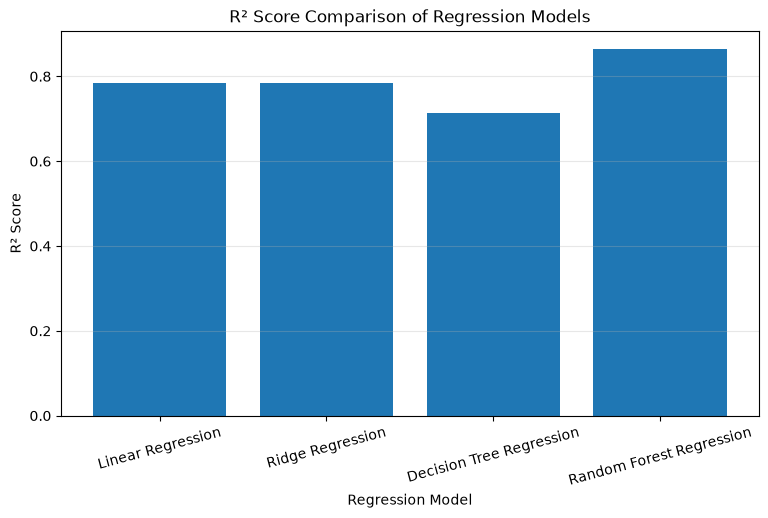

In [12]:
plt.figure(figsize=(9, 5))

plt.bar(
    results_df["Model"],
    results_df["R2 Score"]
)

plt.title("R² Score Comparison of Regression Models")
plt.xlabel("Regression Model")
plt.ylabel("R² Score")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)

plt.show()

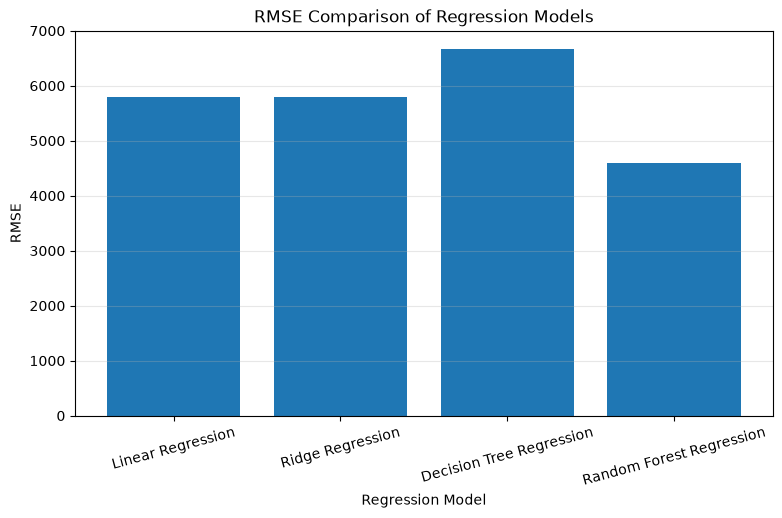

In [13]:
plt.figure(figsize=(9, 5))

plt.bar(
    results_df["Model"],
    results_df["RMSE"]
)

plt.title("RMSE Comparison of Regression Models")
plt.xlabel("Regression Model")
plt.ylabel("RMSE")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [14]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

rf_predictions = rf_pipeline.predict(X_test)

comparison = pd.DataFrame({
    "Actual Charges": y_test.values,
    "Predicted Charges": rf_predictions
})

print(comparison.head(15))

    Actual Charges  Predicted Charges
0       9095.06825       10018.211521
1       5272.17580        5358.565955
2      29330.98315       28119.734273
3       9301.89355       12678.922232
4      33750.29180       34693.408841
5       4536.25900        8590.252063
6       2117.33885        2083.008318
7      14210.53595       14381.966465
8       3732.62510        5861.050998
9      10264.44210       11089.115452
10     18259.21600       19687.416294
11      7256.72310        7278.793332
12      3947.41310        4873.770619
13     46151.12450       46178.320396
14     48673.55880       48393.254922


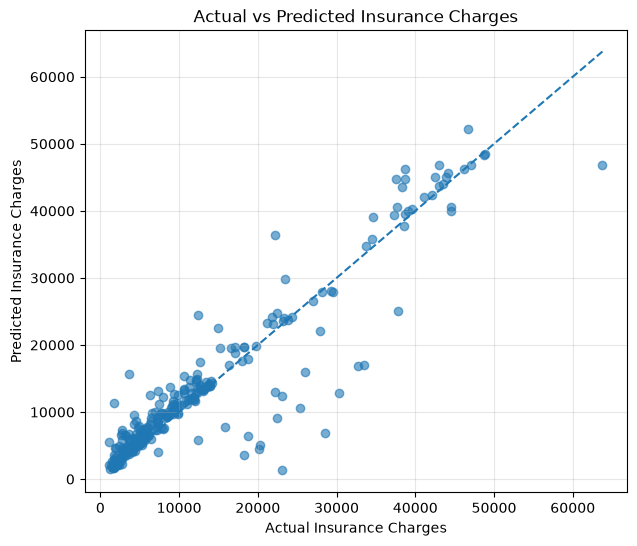

In [15]:
plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Insurance Charges")
plt.ylabel("Predicted Insurance Charges")
plt.title("Actual vs Predicted Insurance Charges")

plt.grid(alpha=0.3)
plt.show()

In [16]:
X_gd = df[["bmi"]].values
y_gd = df["charges"].values

X_train_gd, X_test_gd, y_train_gd, y_test_gd = train_test_split(
    X_gd,
    y_gd,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_gd = scaler.fit_transform(X_train_gd)
X_test_gd = scaler.transform(X_test_gd)

print("Gradient Descent data prepared successfully!")
print("Training samples:", len(X_train_gd))
print("Testing samples:", len(X_test_gd))

Gradient Descent data prepared successfully!
Training samples: 1070
Testing samples: 268


In [17]:
def gradient_descent(X, y, learning_rate=0.01, epochs=1000):

    w = 0.0
    b = 0.0

    n = len(y)

    losses = []

    for epoch in range(epochs):

        y_pred = w * X[:, 0] + b

        error = y_pred - y

        loss = np.mean(error ** 2)
        losses.append(loss)

        dw = (2 / n) * np.sum(error * X[:, 0])
        db = (2 / n) * np.sum(error)

        w = w - learning_rate * dw
        b = b - learning_rate * db

    return w, b, losses

In [18]:
learning_rate = 0.01
epochs = 1000

w, b, losses = gradient_descent(
    X_train_gd,
    y_train_gd,
    learning_rate,
    epochs
)

print("Final Weight:", w)
print("Final Bias:", b)
print("Initial Loss:", losses[0])
print("Final Loss:", losses[-1])

Final Weight: 2370.5368799358293
Final Bias: 13346.089713903459
Initial Loss: 322451733.1842413
Final Loss: 138714176.8150972


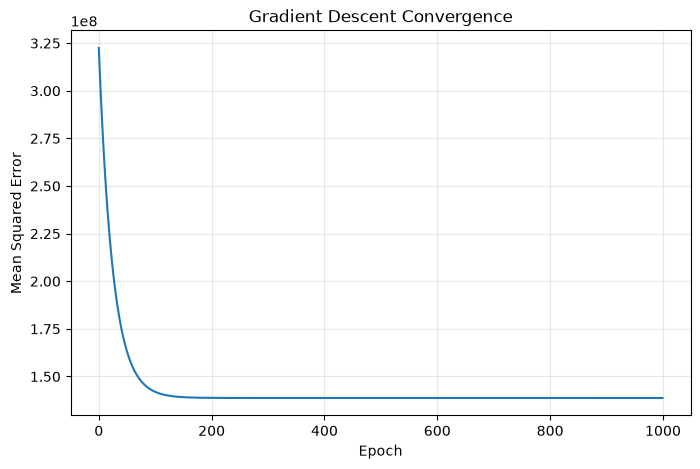

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Gradient Descent Convergence")

plt.grid(alpha=0.3)
plt.show()

In [20]:
gd_predictions = w * X_test_gd[:, 0] + b

gd_mae = mean_absolute_error(y_test_gd, gd_predictions)
gd_mse = mean_squared_error(y_test_gd, gd_predictions)
gd_rmse = np.sqrt(gd_mse)
gd_r2 = r2_score(y_test_gd, gd_predictions)

print("Gradient Descent Performance")
print("----------------------------")
print("MAE :", round(gd_mae, 2))
print("MSE :", round(gd_mse, 2))
print("RMSE:", round(gd_rmse, 2))
print("R²  :", round(gd_r2, 4))

Gradient Descent Performance
----------------------------
MAE : 9784.65
MSE : 149085057.01
RMSE: 12210.04
R²  : 0.0397


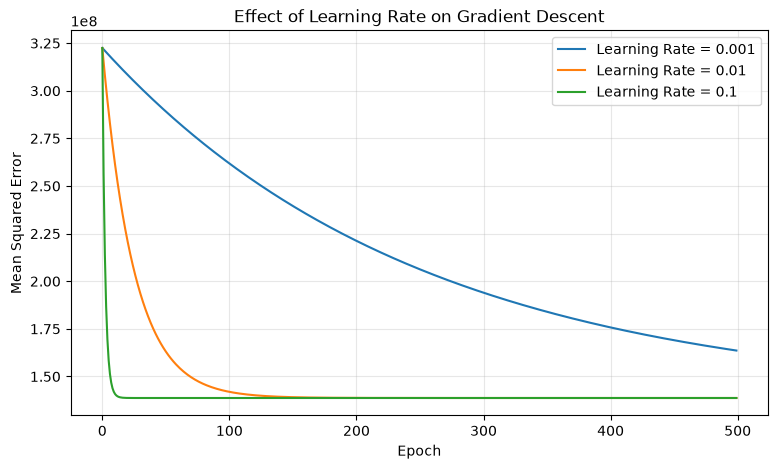

In [21]:
learning_rates = [0.001, 0.01, 0.1]

plt.figure(figsize=(9, 5))

for lr in learning_rates:

    w_temp, b_temp, loss_temp = gradient_descent(
        X_train_gd,
        y_train_gd,
        learning_rate=lr,
        epochs=500
    )

    plt.plot(
        loss_temp,
        label=f"Learning Rate = {lr}"
    )

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Effect of Learning Rate on Gradient Descent")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [22]:
lr_results = []

for lr in learning_rates:

    w_temp, b_temp, loss_temp = gradient_descent(
        X_train_gd,
        y_train_gd,
        learning_rate=lr,
        epochs=500
    )

    lr_results.append({
        "Learning Rate": lr,
        "Initial Loss": loss_temp[0],
        "Final Loss": loss_temp[-1]
    })

lr_df = pd.DataFrame(lr_results)

lr_df["Initial Loss"] = lr_df["Initial Loss"].round(2)
lr_df["Final Loss"] = lr_df["Final Loss"].round(2)

lr_df

,Learning Rate,Initial Loss,Final Loss
0,0.001,3.224517e+08,1.636302e+08
1,0.010,3.224517e+08,1.387142e+08
2,0.100,3.224517e+08,1.387142e+08


In [23]:
print("MEDICAL INSURANCE COST PREDICTION")
print("=" * 45)

print("\nRegression Models Evaluated:")
print("1. Linear Regression")
print("2. Ridge Regression")
print("3. Decision Tree Regression")
print("4. Random Forest Regression")

print("\nEvaluation Metrics:")
print("MAE, MSE, RMSE and R² Score")

print("\nGradient Descent:")
print("Input Feature: BMI")
print("Target: Insurance Charges")
print("Learning rates tested: 0.001, 0.01 and 0.1")
print("Epochs used for main model: 1000")

print("\nPractical completed successfully!")

MEDICAL INSURANCE COST PREDICTION

Regression Models Evaluated:
1. Linear Regression
2. Ridge Regression
3. Decision Tree Regression
4. Random Forest Regression

Evaluation Metrics:
MAE, MSE, RMSE and R² Score

Gradient Descent:
Input Feature: BMI
Target: Insurance Charges
Learning rates tested: 0.001, 0.01 and 0.1
Epochs used for main model: 1000

Practical completed successfully!
